In [ ]:
from dataloaders import SequentialCIFAR10
from torch.optim import AdamW
from tqdm.auto import tqdm
from torch import optim
from torch import nn
import torch
import torch.nn.functional as F
from losses import SupConLoss
import matplotlib.pyplot as plt
import numpy as np
from models import *
from umap import UMAP


In [4]:
seq_cifar = SequentialCIFAR10(data_root="./data", batch_size=32, buffer_size=200)
train_loader, val_loader = seq_cifar.get_train_val_loaders(task_id=0, use_buffer=False)

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CNN(in_channels=3, embedding_dim=32).to(device)
criterion = SupConLoss(tau=0.07)
optimizer = AdamW(model.parameters(), lr=5e-5)
model2 = CNN(in_channels=3, embedding_dim=32).to(device)


In [ ]:
def collect_embeddings(model, dataloader, device="cpu", max_samples=2000):
    model.eval()
    all_embeddings = []
    all_labels = []
    collected = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            embeddings = model(images)
            all_embeddings.append(embeddings.detach().cpu())
            all_labels.append(labels.detach().cpu())

            collected += labels.size(0)
            if max_samples is not None and collected >= max_samples:
                break

    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0)

    if max_samples is not None:
        embeddings = embeddings[:max_samples]
        labels = labels[:max_samples]

    return embeddings.numpy(), labels.numpy()


def plot_umap_embeddings(embeddings, labels, title, random_state=42):
    if UMAP is None:
        raise ImportError("UMAP is not installed. Install it with: pip install umap-learn")

    reducer = UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.1,
        metric="cosine",
        random_state=random_state,
    )
    projected = reducer.fit_transform(embeddings)

    unique_labels = np.unique(labels)
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    indexed_labels = np.array([label_to_index[label] for label in labels])

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        projected[:, 0],
        projected[:, 1],
        c=indexed_labels,
        cmap=plt.get_cmap("tab20", len(unique_labels)),
        vmin=-0.5,
        vmax=len(unique_labels) - 0.5,
        s=14,
        alpha=0.85,
    )
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    colorbar = plt.colorbar(scatter, ticks=np.arange(len(unique_labels)))
    colorbar.set_label("Class")
    colorbar.ax.set_yticklabels(unique_labels.astype(int))

    plt.tight_layout()
    plt.show()


def train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    criterion,
    lr_scheduler=None,
    num_epochs=10,
    device="cpu",
    umap_dataloader=None,
    plot_umap_every=0,
    umap_max_samples=2000,
):
    train_losses = []
    val_losses = []

    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()
        running_loss = 0.0

        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            embeddings = model(images)
            loss = criterion(embeddings, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if lr_scheduler is not None:
                lr_scheduler.step()

            running_loss += loss.item()
        train_losses.append(running_loss / len(train_dataloader))

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_dataloader:
                images = images.to(device)
                labels = labels.to(device)
                embeddings = model(images)
                loss = criterion(embeddings, labels)
                running_val_loss += loss.item()

        val_losses.append(running_val_loss / len(val_dataloader))

        should_plot = (
            plot_umap_every is not None
            and plot_umap_every > 0
            and umap_dataloader is not None
            and ((epoch + 1) % plot_umap_every == 0 or (epoch + 1) == num_epochs)
        )
        if should_plot:
            epoch_embeddings, epoch_labels = collect_embeddings(
                model,
                umap_dataloader,
                device=device,
                max_samples=umap_max_samples,
            )
            plot_umap_embeddings(
                epoch_embeddings,
                epoch_labels,
                title=f"UMAP clusters during training (epoch {epoch + 1})",
            )

    return train_losses, val_losses

Training:   0%|          | 0/10 [00:00<?, ?it/s]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:  10%|█         | 1/10 [00:38<05:42, 38.02s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


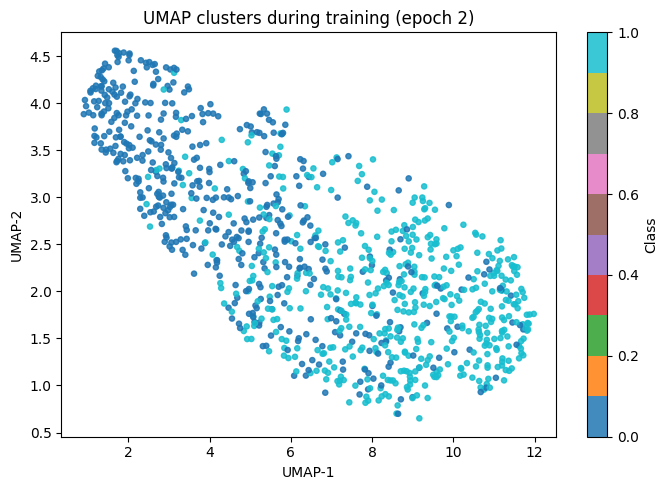

Training:  20%|██        | 2/10 [01:32<06:20, 47.59s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:  30%|███       | 3/10 [02:08<04:55, 42.18s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


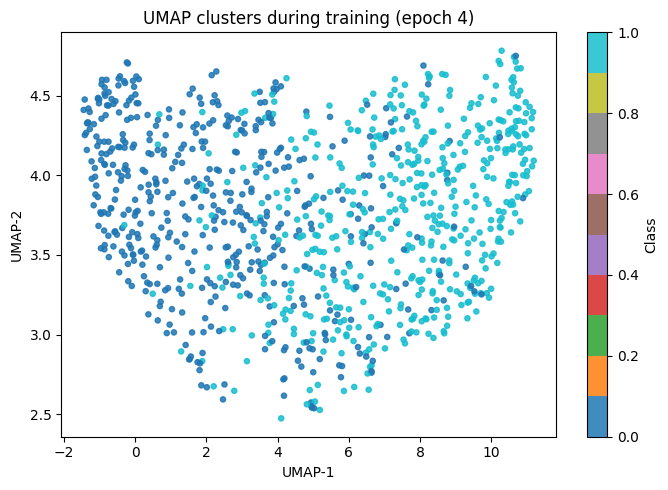

Training:  40%|████      | 4/10 [02:59<04:35, 45.93s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:  50%|█████     | 5/10 [03:40<03:41, 44.23s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


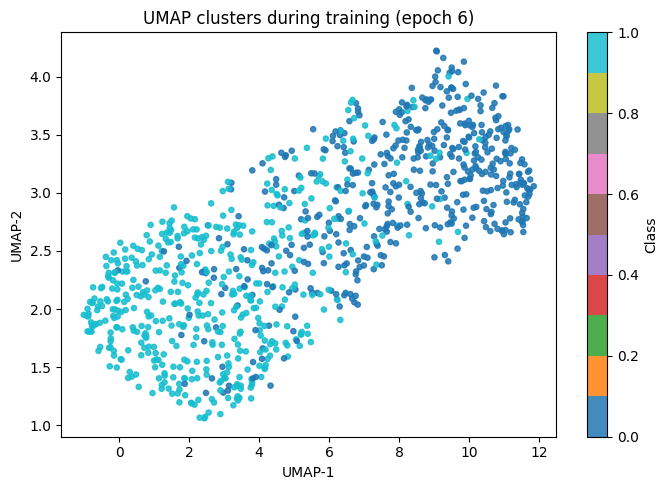

Training:  60%|██████    | 6/10 [04:35<03:10, 47.60s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:  70%|███████   | 7/10 [05:10<02:10, 43.52s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


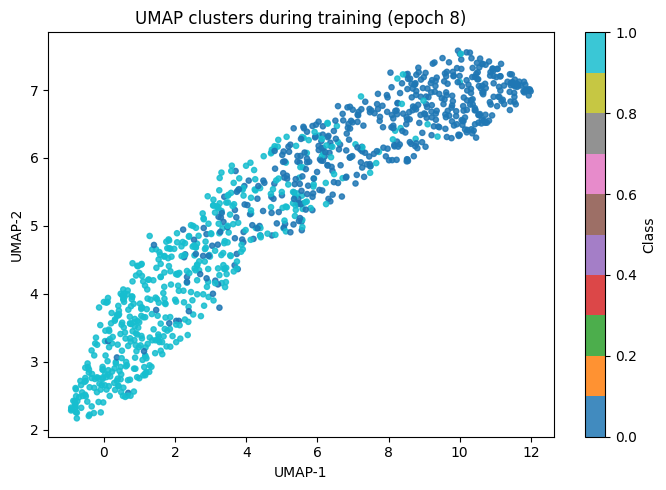

Training:  80%|████████  | 8/10 [06:06<01:35, 47.68s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:  90%|█████████ | 9/10 [06:43<00:44, 44.26s/it]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


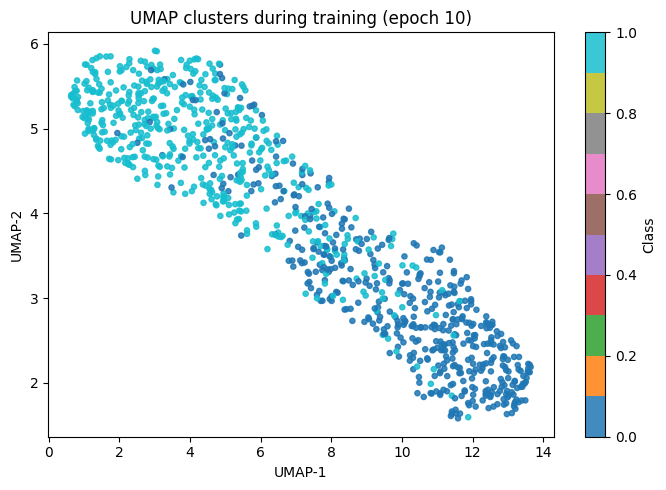

Training: 100%|██████████| 10/10 [07:41<00:00, 46.13s/it]


In [8]:
train_losses, val_losses = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    lr_scheduler=None,
    num_epochs=10,
    device=device,
    umap_dataloader=val_loader,
    plot_umap_every=2,
    umap_max_samples=2000,
)

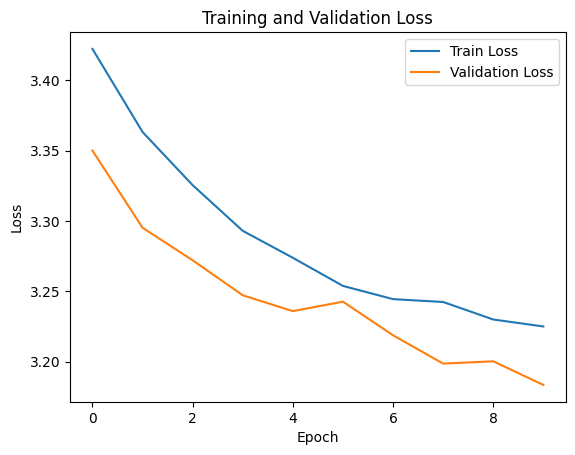

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [14]:
import os

os.makedirs("checkpoints", exist_ok=True)
checkpoint_path = "checkpoints/supcon_backbone_task0.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
}, checkpoint_path)

print(f"Backbone weights saved to: {checkpoint_path}")

Backbone weights saved to: checkpoints/supcon_backbone_task0.pt


In [ ]:


num_classes_task0 = len(seq_cifar.task_classes[0])
linear_probe = LinearProbe(model, embedding_dim=32, num_classes=num_classes_task0).to(device)
linear_probe_criterion = nn.CrossEntropyLoss()
linear_probe_optimizer = AdamW(linear_probe.classifier.parameters(), lr=1e-3)

print("Linear probe ready: backbone frozen, classifier trainable.")

Linear probe ready: backbone frozen, classifier trainable.


In [11]:
def train_linear_probe_task0(
    linear_probe,
    train_dataloader,
    val_dataloader,
    optimizer,
    criterion,
    device,
    num_epochs=10,
    class_offset=0,
):
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_acc = -1.0
    best_classifier_state = None

    for epoch in range(num_epochs):
        linear_probe.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device) - class_offset

            logits = linear_probe(images)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_dataloader)
        train_acc = correct / total

        linear_probe.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_dataloader:
                images = images.to(device)
                labels = labels.to(device) - class_offset

                logits = linear_probe(images)
                val_loss = criterion(logits, labels)

                val_running_loss += val_loss.item()
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / len(val_dataloader)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_classifier_state = {
                key: value.detach().cpu().clone()
                for key, value in linear_probe.classifier.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_classifier_state is not None:
        linear_probe.classifier.load_state_dict(best_classifier_state)

    print(f"Best validation accuracy (task 0): {best_val_acc:.4f}")
    return history

task0_classes = seq_cifar.task_classes[0]
task0_offset = min(task0_classes)

linear_probe_history = train_linear_probe_task0(
    linear_probe=linear_probe,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=linear_probe_optimizer,
    criterion=linear_probe_criterion,
    device=device,
    num_epochs=10,
    class_offset=task0_offset,
)

/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/10 | train_loss=0.5763 train_acc=0.8323 | val_loss=0.5002 val_acc=0.8630
Epoch 02/10 | train_loss=0.4434 train_acc=0.8740 | val_loss=0.4159 val_acc=0.8530
Epoch 03/10 | train_loss=0.3780 train_acc=0.8772 | val_loss=0.3662 val_acc=0.8730
Epoch 04/10 | train_loss=0.3475 train_acc=0.8720 | val_loss=0.3610 val_acc=0.8620
Epoch 05/10 | train_loss=0.3231 train_acc=0.8797 | val_loss=0.3307 val_acc=0.8700
Epoch 06/10 | train_loss=0.3141 train_acc=0.8789 | val_loss=0.3474 val_acc=0.8430
Epoch 07/10 | train_loss=0.3041 train_acc=0.8778 | val_loss=0.3245 val_acc=0.8510


Python(53836) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(53841) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(53879) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(53888) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 08/10 | train_loss=0.2961 train_acc=0.8796 | val_loss=0.3203 val_acc=0.8730


Python(53918) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(53923) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(53963) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(53972) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 09/10 | train_loss=0.3028 train_acc=0.8739 | val_loss=0.3293 val_acc=0.8650


Python(54008) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(54013) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(54054) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(54061) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 10/10 | train_loss=0.2944 train_acc=0.8781 | val_loss=0.3059 val_acc=0.8720
Best validation accuracy (task 0): 0.8730


Best epoch: 3
Train accuracy at best epoch: 0.8772
Validation accuracy at best epoch: 0.8730


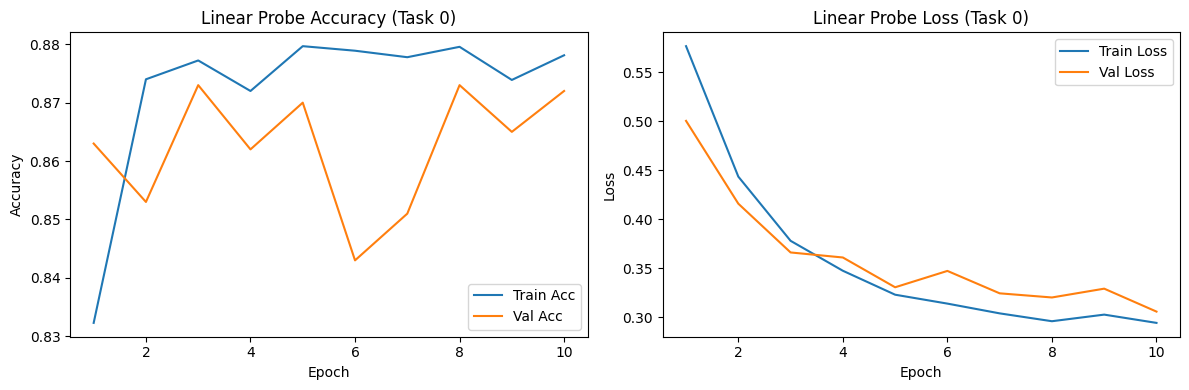

In [12]:
epochs = range(1, len(linear_probe_history["train_acc"]) + 1)
best_epoch = int(max(range(len(linear_probe_history["val_acc"])), key=lambda i: linear_probe_history["val_acc"][i])) + 1
best_val_acc = linear_probe_history["val_acc"][best_epoch - 1]
best_train_acc = linear_probe_history["train_acc"][best_epoch - 1]

print(f"Best epoch: {best_epoch}")
print(f"Train accuracy at best epoch: {best_train_acc:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, linear_probe_history["train_acc"], label="Train Acc")
axes[0].plot(epochs, linear_probe_history["val_acc"], label="Val Acc")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Linear Probe Accuracy (Task 0)")
axes[0].legend()

axes[1].plot(epochs, linear_probe_history["train_loss"], label="Train Loss")
axes[1].plot(epochs, linear_probe_history["val_loss"], label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Linear Probe Loss (Task 0)")
axes[1].legend()

plt.tight_layout()
plt.show()

Python(54097) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(54112) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Task 0 test accuracy (linear probe): 0.9000


Python(54149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(54254) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


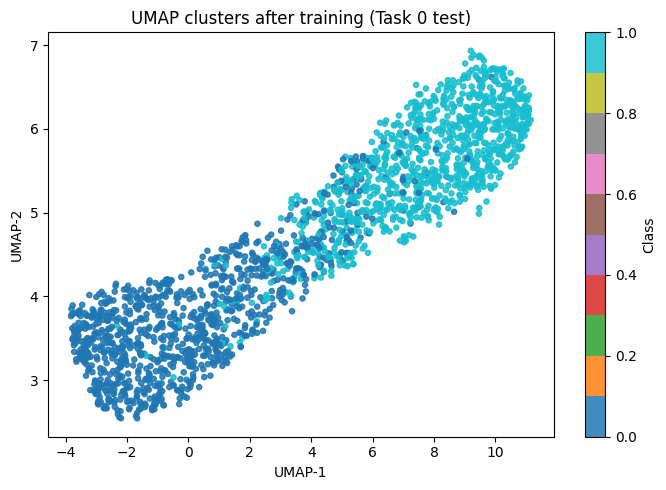

In [13]:
task0_test_loader = seq_cifar.get_task_il_test_loaders(up_to_task=0)[0]

linear_probe.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in task0_test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = linear_probe(images)
        preds = logits.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

task0_test_acc = test_correct / test_total
print(f"Task 0 test accuracy (linear probe): {task0_test_acc:.4f}")

final_embeddings, final_labels = collect_embeddings(
    model,
    task0_test_loader,
    device=device,
    max_samples=2000,
)
plot_umap_embeddings(
    final_embeddings,
    final_labels,
    title="UMAP clusters after training (Task 0 test)",
)

In [ ]:
import os

os.makedirs("checkpoints", exist_ok=True)
linear_head_path = "checkpoints/linear_probe_head_task0.pt"

# Save only the linear head (classifier) weights
torch.save(
    {
        "classifier_state_dict": linear_probe.classifier.state_dict(),
        "num_classes": linear_probe.classifier.out_features,
        "in_features": linear_probe.classifier.in_features,
    },
    linear_head_path,
)
print(f"Linear head saved to: {linear_head_path}")

Linear head saved to: checkpoints/linear_probe_head_task0.pt
Linear head loaded successfully.
Loaded head dims: in_features=32, num_classes=2


In [18]:
head_ckpt = torch.load("checkpoints/linear_probe_head_task0.pt", map_location=device)
backbone_ckpt = torch.load("checkpoints/supcon_backbone_task0.pt", map_location=device)

# Recreate backbone model object, then load its state_dict
backbone_model = CNN(in_channels=3, embedding_dim=32).to(device)
backbone_model.load_state_dict(backbone_ckpt["model_state_dict"])
backbone_model.eval()

# Recreate linear probe with backbone model and load linear head
reloaded_linear_probe = LinearProbe(
    backbone_model,
    embedding_dim=32,
    num_classes=head_ckpt["num_classes"],
).to(device)
reloaded_linear_probe.classifier.load_state_dict(head_ckpt["classifier_state_dict"])
reloaded_linear_probe.eval()

print("Backbone + linear head loaded successfully into reloaded_linear_probe.")

Backbone + linear head loaded successfully into reloaded_linear_probe.
